In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import Point, LineString


def plot_clusters_map(
    cluster_df,
    data_sources_path="dataset/icecore/data_sources.csv",
    cluster_col="Level_0",
    title="Clustering Result",
):
    coords = pd.read_csv(data_sources_path)[
        ["site", "Latitude", "Longitude"]
    ].rename(columns={"Latitude": "lat", "Longitude": "lon"})

    df = cluster_df.merge(coords, on="site", how="left")
    df[["lat", "lon"]] = df[["lat", "lon"]].apply(pd.to_numeric, errors="coerce")
    df = df.dropna(subset=["lat", "lon", cluster_col]).copy()
    df[cluster_col] = df[cluster_col].astype(int)

    assert len(df) == len(cluster_df), "部分聚类站点没有匹配到坐标"

    sites = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326",
    ).to_crs(3031)

    world = gpd.read_file(
        "https://naturalearth.s3.amazonaws.com/"
        "110m_cultural/ne_110m_admin_0_countries.zip"
    )
    antarctica = world[world["NAME"] == "Antarctica"].to_crs(3031)

    land = antarctica.unary_union
    boundary = land.boundary
    minx, miny, maxx, maxy = land.bounds

    x = np.linspace(minx, maxx, 300)
    y = np.linspace(miny, maxy, 300)
    xx, yy = np.meshgrid(x, y)

    grid = gpd.GeoSeries(
        gpd.points_from_xy(xx.ravel(), yy.ravel()),
        crs="EPSG:3031",
    )
    inside = grid.within(land)

    elevation = np.zeros(len(grid))
    elevation[inside] = grid[inside].distance(boundary)
    elevation = 3.26 * np.sqrt(elevation)
    elevation = elevation.reshape(xx.shape)
    elevation[~inside.to_numpy().reshape(xx.shape)] = np.nan

    elevation_cmap = mcolors.LinearSegmentedColormap.from_list(
        "ice_elevation",
        ["#2b8cbe", "#a6bddb", "#ece7f2", "#ffffff"],
    )

    latitude_lines = [
        LineString((lon, lat) for lon in np.linspace(-180, 180, 360))
        for lat in [-80, -70, -60]
    ]
    longitude_lines = [
        LineString([(lon, -90), (lon, -55)])
        for lon in range(-180, 180, 30)
    ]
    grid_lines = gpd.GeoDataFrame(
        geometry=latitude_lines + longitude_lines,
        crs="EPSG:4326",
    ).to_crs(3031)

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_facecolor("#08306b")

    padding = 750000
    ax.set_xlim(minx - padding, maxx + padding * 2.2)
    ax.set_ylim(miny - padding, maxy + padding)

    contour = ax.contourf(
        xx,
        yy,
        elevation,
        levels=np.linspace(0, 4200, 15),
        cmap=elevation_cmap,
        zorder=1,
    )
    antarctica.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=2)
    grid_lines.plot(
        ax=ax,
        color="white",
        linewidth=0.5,
        linestyle="--",
        alpha=0.5,
        zorder=3,
    )

    label_style = dict(
        color="#333333",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        zorder=10,
        bbox=dict(
            facecolor="#f0f0f0",
            edgecolor="none",
            alpha=0.75,
            boxstyle="round,pad=0.2",
        ),
    )

    for lon in range(-180, 180, 30):
        point = gpd.GeoSeries(
            [Point(lon, -60)], crs="EPSG:4326"
        ).to_crs(3031).iloc[0]

        if lon == 0:
            label = "0°"
        elif lon == -180:
            label = "180°"
        else:
            label = f"{abs(lon)}°{'E' if lon > 0 else 'W'}"

        ax.text(point.x, point.y, label, **label_style)

    for lat in [-80, -70, -60]:
        point = gpd.GeoSeries(
            [Point(45, lat)], crs="EPSG:4326"
        ).to_crs(3031).iloc[0]
        ax.text(point.x, point.y, f"{abs(lat)}°S", **label_style)

    colorbar = fig.colorbar(contour, ax=ax, fraction=0.036, pad=0.04)
    colorbar.set_label("Approximate Elevation (m)", fontsize=12)

    cluster_ids = sorted(sites[cluster_col].unique())

    for cluster_id in cluster_ids:
        group = sites[sites[cluster_col] == cluster_id]

        ax.scatter(
            group.geometry.x,
            group.geometry.y,
            label=f"Cluster {cluster_id}",
            s=120,
            edgecolors="black",
            linewidth=1.5,
            alpha=0.9,
            zorder=5,
        )

    ax.legend(
        loc="center right",
        title="Clusters",
        framealpha=0.9,
        fontsize=9,
    )
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.axis("off")
    fig.tight_layout()

    plt.show()

/Users/liulei/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/liulei/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


def cluster_sites(
    csv_path,
    support_ratio=0.8,
    z_score=True,
    n_clusters=3,
    random_state=42,
):
    if not 0 < support_ratio <= 1:
        raise ValueError("support_ratio 必须在 (0, 1] 内")

    df = pd.read_csv(csv_path).sort_values("year")
    support_len = int(len(df) * support_ratio)

    if support_len < 2:
        raise ValueError("support 至少需要两个年份")

    X = df.iloc[:support_len].drop(columns="year").T.astype(float)

    if X.isna().any().any():
        raise ValueError("support 数据中存在缺失值")

    if z_score:
        mean = X.mean(axis=1)
        std = X.std(axis=1, ddof=0).replace(0, 1)
        X = X.sub(mean, axis=0).div(std, axis=0)

    site_names = X.index

    labels = KMeans(
        n_clusters=n_clusters,
        n_init=50,
        random_state=random_state,
    ).fit_predict(X)

    cluster_df = pd.DataFrame({
        "site": site_names,
        "Level_0": labels,
    })

    plot_clusters_map(
        cluster_df,
        data_sources_path="dataset/icecore/data_sources.csv",
        title="Clustering Result",
    )

    return cluster_df

/var/folders/hd/g7jx9qfj79d3h4lpjzp1p8j80000gn/T/ipykernel_68048/3158850164.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  land = antarctica.unary_union


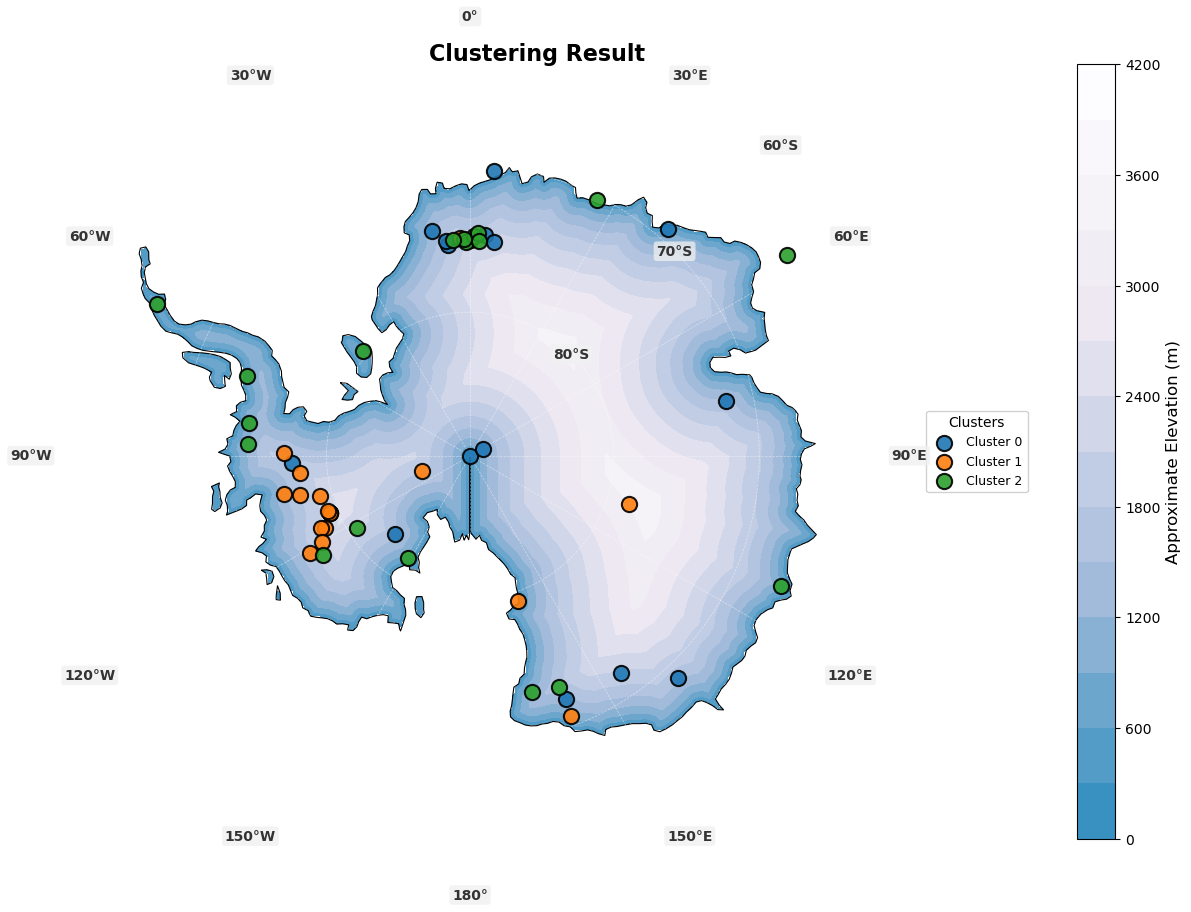

/var/folders/hd/g7jx9qfj79d3h4lpjzp1p8j80000gn/T/ipykernel_68048/3158850164.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  land = antarctica.unary_union


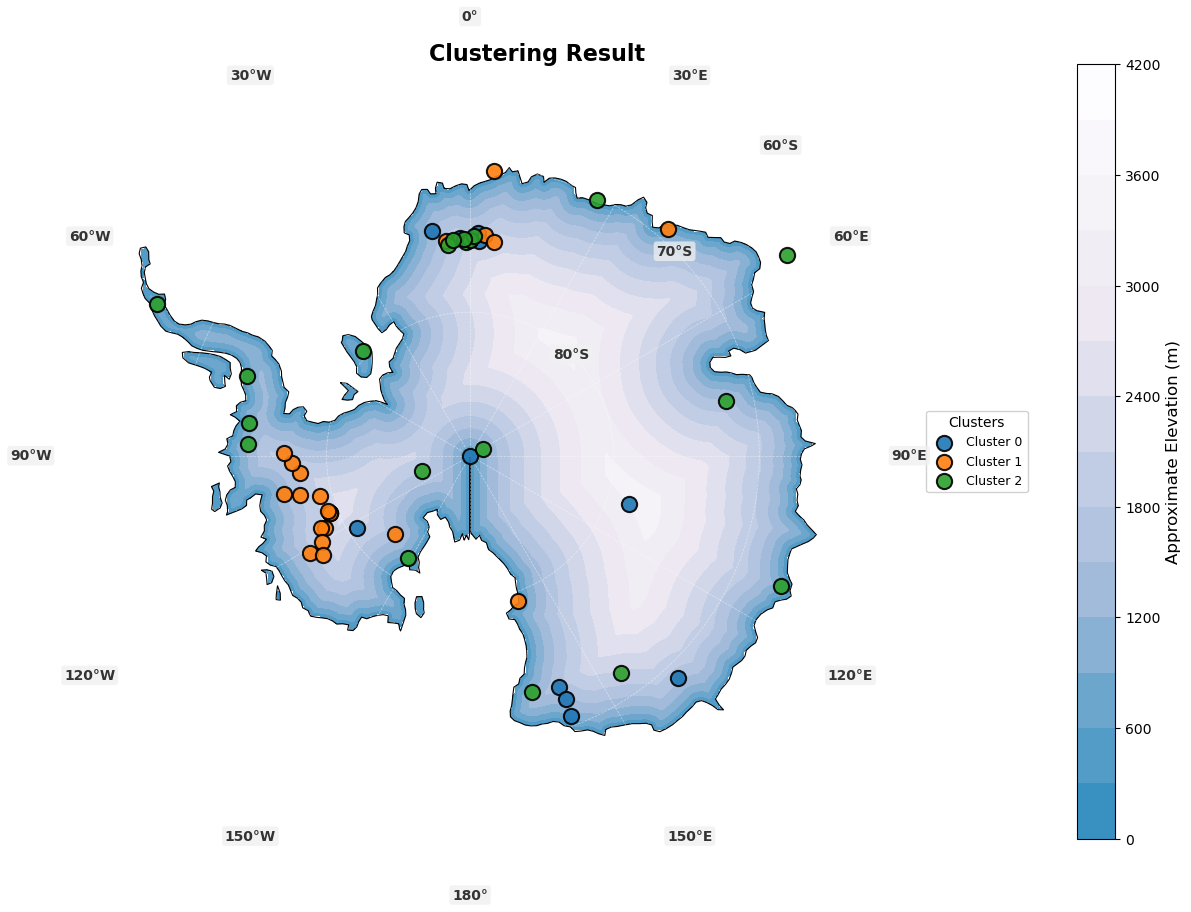

In [15]:
cluster_zscore_accum_supp = cluster_sites(
    "dataset/icecore/accum/accum_100y.csv",
    support_ratio=0.66,
    z_score=True,
    n_clusters=3,
)
cluster_zscore_accum_supp.to_csv("cluster/accum/accum_100y_cluster_supp.csv", index=False)

cluster_zscore_accum = cluster_sites(
    "dataset/icecore/accum/accum_100y.csv",
    support_ratio=1,
    z_score=True,
    n_clusters=3,
)
cluster_zscore_accum.to_csv("cluster/accum/accum_100y_cluster.csv", index=False)

/var/folders/hd/g7jx9qfj79d3h4lpjzp1p8j80000gn/T/ipykernel_68048/3158850164.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  land = antarctica.unary_union


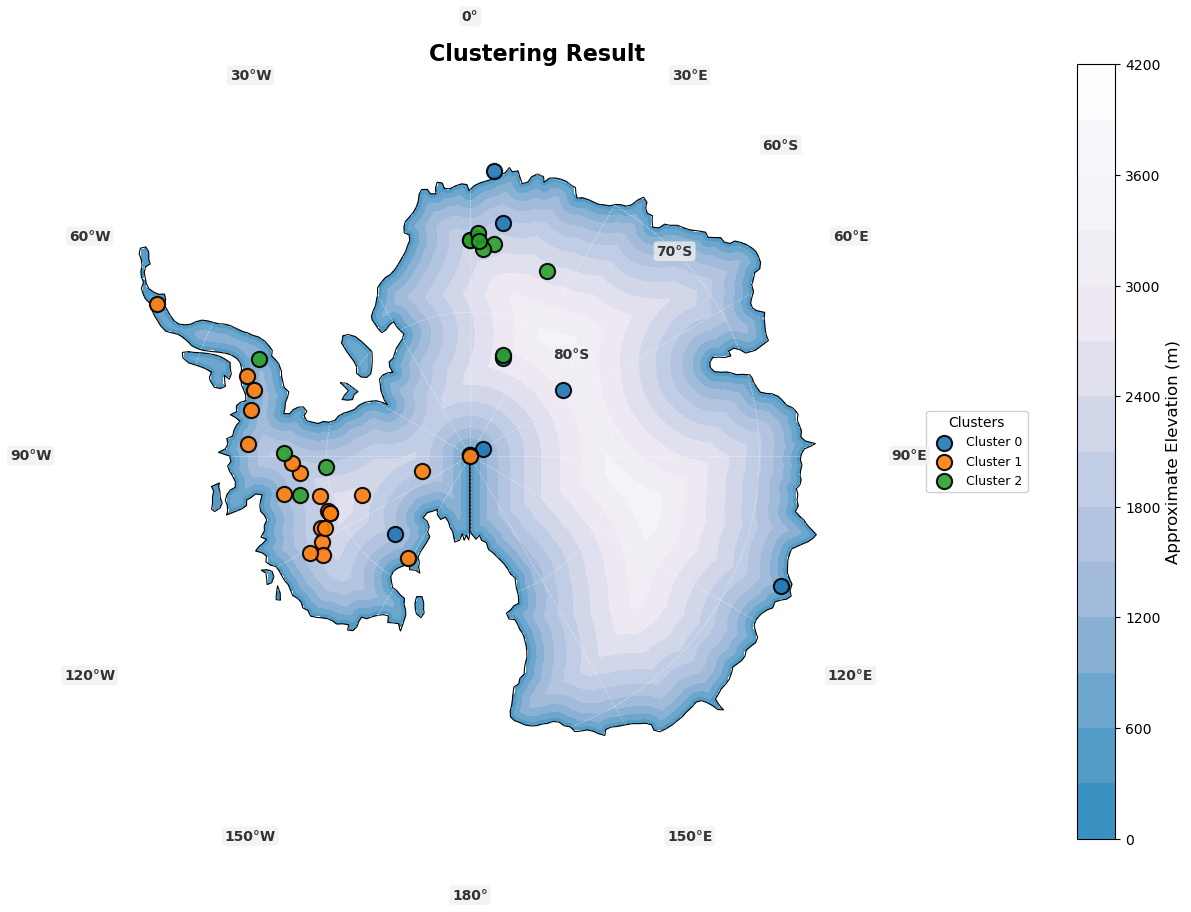

/var/folders/hd/g7jx9qfj79d3h4lpjzp1p8j80000gn/T/ipykernel_68048/3158850164.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  land = antarctica.unary_union


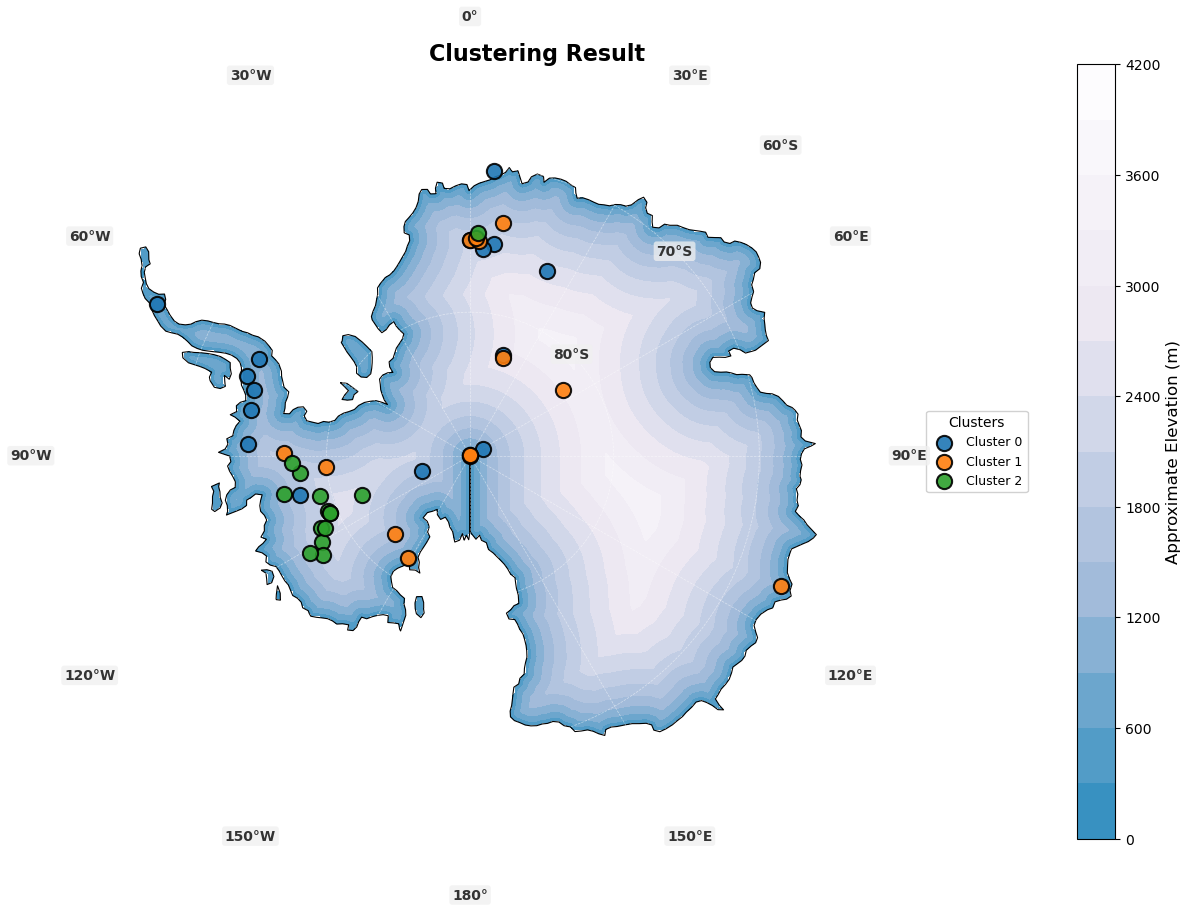

In [16]:
cluster_zscore_chem_supp = cluster_sites(
    "dataset/icecore/chem/chem.csv",
    support_ratio=0.66,
    z_score=True,
    n_clusters=3,
)
cluster_zscore_chem_supp.to_csv("cluster/chem/chem_cluster_supp.csv", index=False)

cluster_zscore_chem = cluster_sites(
    "dataset/icecore/chem/chem.csv",
    support_ratio=1,
    z_score=True,
    n_clusters=3,
)
cluster_zscore_chem.to_csv("cluster/chem/chem_cluster.csv", index=False)

In [6]:
import numpy as np
import pandas as pd

from mvlearn.cluster import (
    MultiviewKMeans,
    MultiviewSpectralClustering,
    MultiviewCoRegSpectralClustering,
)

support_ratio = 0.66

accum = pd.read_csv("dataset/icecore/accum/accum_100y.csv").set_index("year")
chem = pd.read_csv("dataset/icecore/chem/chem.csv").set_index("year")

years = sorted(accum.index.intersection(chem.index))
sites = sorted(accum.columns.intersection(chem.columns))
support_years = years[:int(len(years) * support_ratio)]

X_accum = accum.loc[support_years, sites].T.to_numpy(float)
X_chem = chem.loc[support_years, sites].T.to_numpy(float)

X_accum = (X_accum - X_accum.mean()) / X_accum.std()
X_chem = (X_chem - X_chem.mean()) / X_chem.std()

Xs = [X_accum, X_chem]

/Users/liulei/anaconda3/lib/python3.11/site-packages/mvlearn/cluster/mv_kmeans.py:333: ConvergenceWarning: Number of distinct cluster centroids (2) found is smaller than n_clusters (3).
  warnings.warn(msg, ConvergenceWarning)
/var/folders/hd/g7jx9qfj79d3h4lpjzp1p8j80000gn/T/ipykernel_68048/3158850164.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  land = antarctica.unary_union


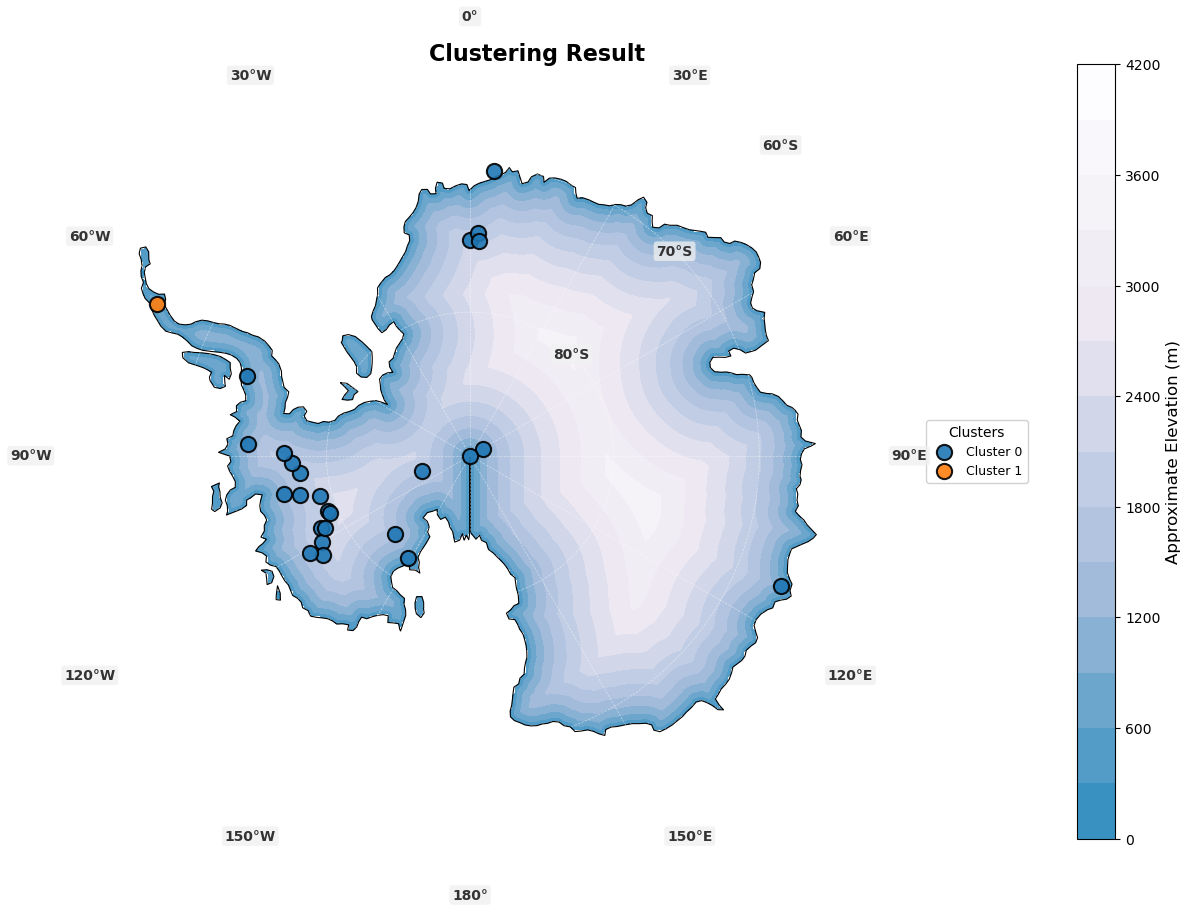

In [7]:
labels_kmeans = MultiviewKMeans(
    n_clusters=3,
    random_state=42,
).fit_predict(Xs)

cluster_kmeans = pd.DataFrame({
    "site": sites,
    "Level_0": labels_kmeans,
})

plot_clusters_map(
    cluster_kmeans,
    data_sources_path="dataset/icecore/data_sources.csv",
    title="Clustering Result",
)

/var/folders/hd/g7jx9qfj79d3h4lpjzp1p8j80000gn/T/ipykernel_68048/3158850164.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  land = antarctica.unary_union


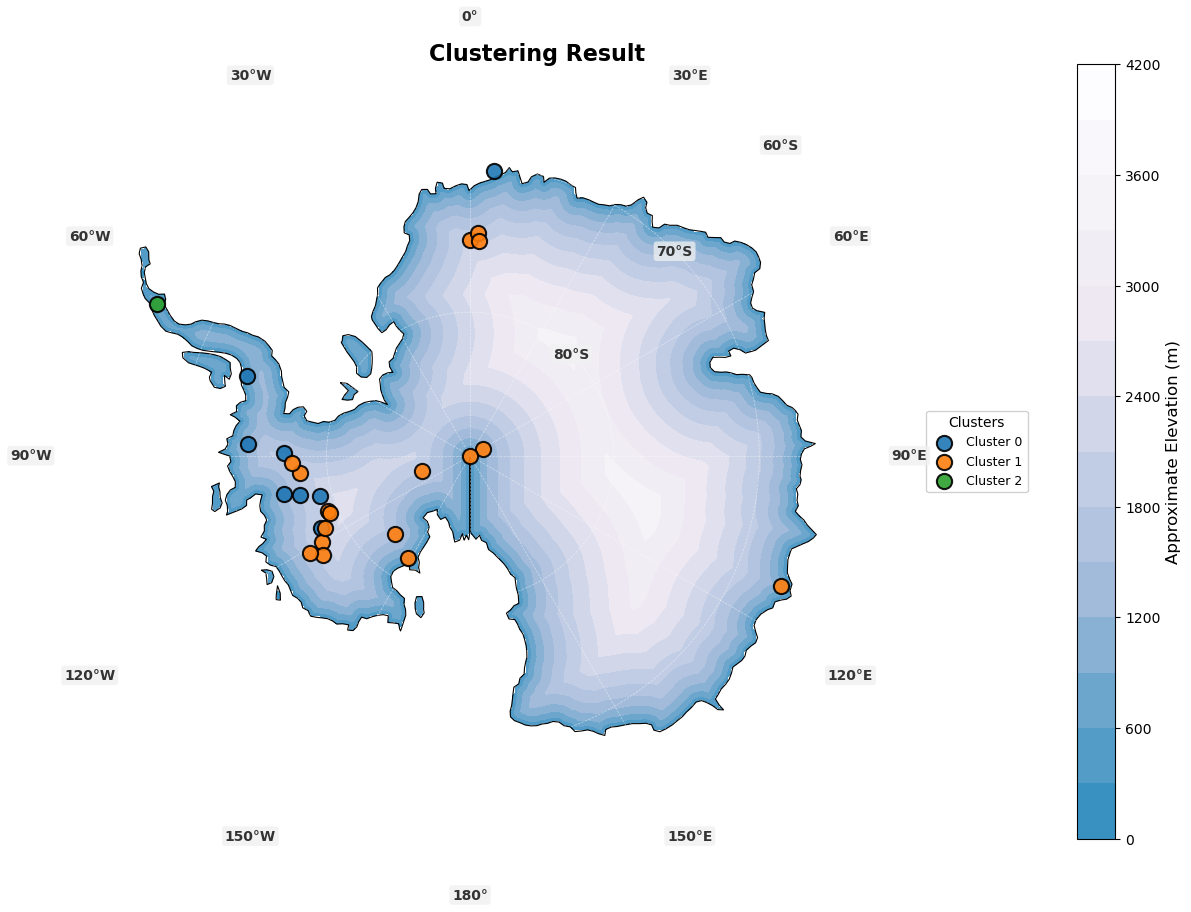

In [8]:
labels_spectral = MultiviewSpectralClustering(
    n_clusters=3,
    random_state=42,
).fit_predict(Xs)

cluster_spectral = pd.DataFrame({
    "site": sites,
    "Level_0": labels_spectral,
})
plot_clusters_map(
    cluster_spectral,
    data_sources_path="dataset/icecore/data_sources.csv",
    title="Clustering Result",
)

/var/folders/hd/g7jx9qfj79d3h4lpjzp1p8j80000gn/T/ipykernel_68048/3158850164.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  land = antarctica.unary_union


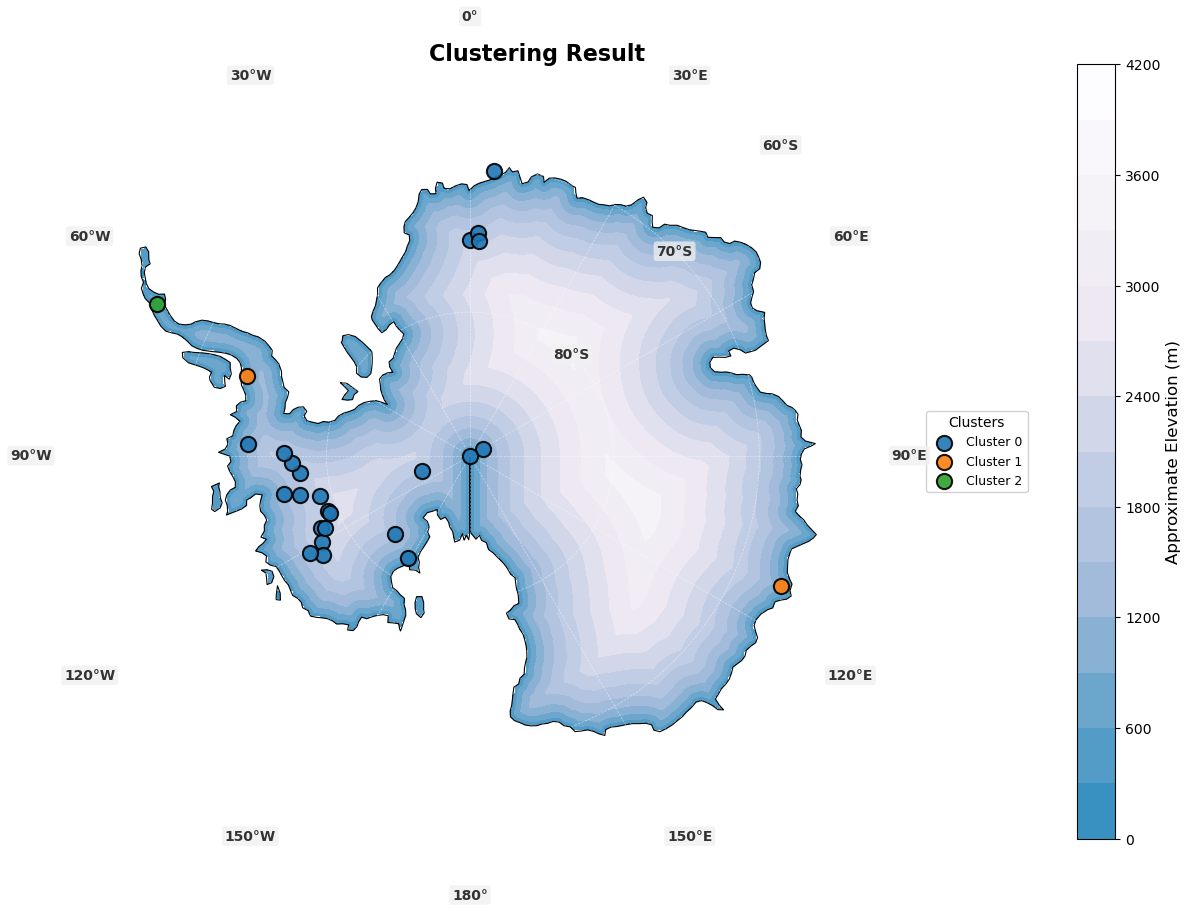

In [9]:
labels_coreg = MultiviewCoRegSpectralClustering(
    n_clusters=3,
    random_state=42,
).fit_predict(Xs)

cluster_coreg = pd.DataFrame({
    "site": sites,
    "Level_0": labels_coreg,
})
plot_clusters_map(
    cluster_coreg,
    data_sources_path="dataset/icecore/data_sources.csv",
    title="Clustering Result",
)